In [1]:
from datetime import date
from pathlib import Path

from tapas_gmm.env.rlbench import RLBenchEnvironment, RLBenchEnvironmentConfig
from tapas_gmm.policy.gmm import GMMPolicy, GMMPolicyConfig
from tapas_gmm.policy.models.tpgmm import AutoTPGMMConfig

from rlbench.action_modes.arm_action_modes import BimanualEndEffectorPoseViaIK

import imageio.v2 as imageio

2026-07-27 01:28:52.196 | INFO     |  Running on cpu


/home/nils-schmidt/Dokumente/Study Project/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
checkpoint_root = Path("../artifacts/checkpoints/tapas")
checkpoint_dir = max(path for path in checkpoint_root.iterdir() if path.is_dir())
model_path = checkpoint_dir / "latest.pkl"
video_dir = Path("../artifacts/videos/tapas") / date.today().isoformat()
video_dir.mkdir(parents=True, exist_ok=True)

In [3]:
tapas_env = RLBenchEnvironment(
    RLBenchEnvironmentConfig(
        action_mode = BimanualEndEffectorPoseViaIK,
        robot_setup = "dual_panda",
        task = "BimanualDualPushButtons",
        cameras = ("front",),
        camera_pose = {},
        image_size = (128, 128),
        static = False,
        headless = False,
        scale_action = False,
        delay_gripper = False,
        gripper_plot = False,   
    )
)

policy = GMMPolicy(
    GMMPolicyConfig(
        suffix=None,
        model = AutoTPGMMConfig(),
        batch_predict_in_t_models = False,
        topp_in_t_models = False,
        dbg_prediction = True,
        binary_gripper_action = True,
        force_overwrite_checkpoint_config = True,
        pos_lag_thresh=0.03,
        quat_change_thresh=0.1,
    )
)

2026-07-27 01:29:01.635 | INFO     |  Initializing Policy:
2026-07-27 01:29:01.636 | INFO     |  No encoder config provided. Using None.
None


2026-07-27 01:29:03.571 | INFO     |  Loading model:
2026-07-27 01:29:03.670 | ERROR    |  Config mismatch
root.demos_segmentation.min_n_components 3 != 1
root.demos_segmentation.distance_based False != True
root.demos_segmentation.components_prop_to_len True != False
root.demos_segmentation.velocity_based True != False
root.tpgmm.reg_diag_gripper 0.02 != 0.1
root.tpgmm.add_gripper_action True != False
root.tpgmm.reg_diag  0.0002 != 0.001
root.tpgmm.reg_em_finish_diag 0.0002 != 0.001
root.tpgmm.reg_em_finish_diag_gripper 0.02 != 0.1
root.tpgmm.add_time_component True != False
root.tpgmm.add_action_component False != True
root.tpgmm.n_components 10 != 4
root.tpgmm.reg_em_trans 1e-06 != None
root.tpgmm.reg_init_diag 0.0005 != 5e-05
root.frame_selection.rel_score_threshold 0.1 != 0.75

2026-07-27 01:29:03.670 | WARNING  |  Overwriting config. This can lead to unexpected errors.
2026-07-27 01:29:03.671 | INFO     |  Detected time-based model: True. Using time-driven policy. Set time_based 

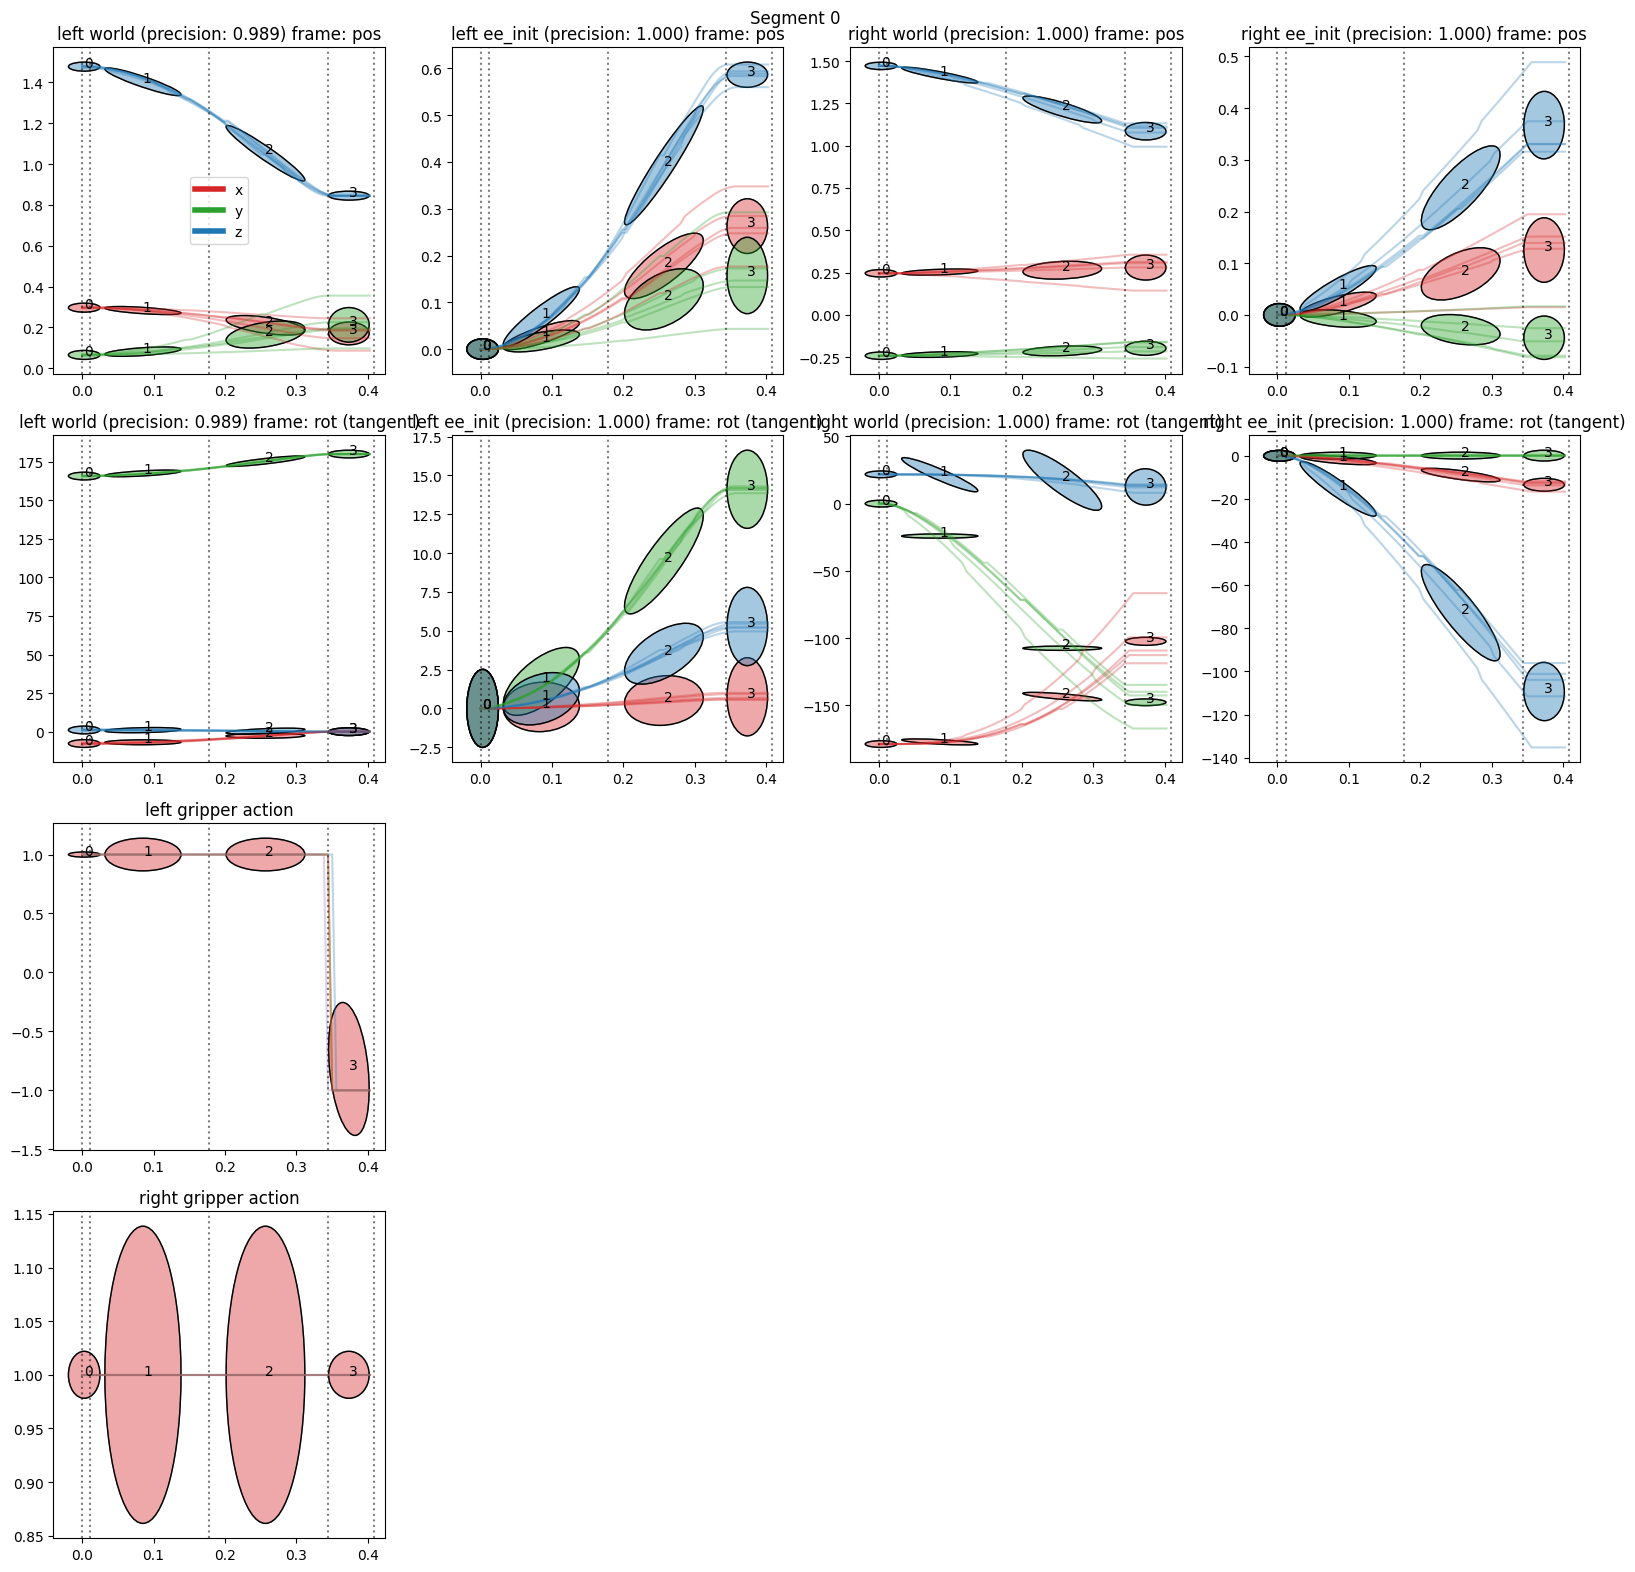

2026-07-27 01:29:07.410 | INFO     |  Did not specify time_based, deciding automatically.


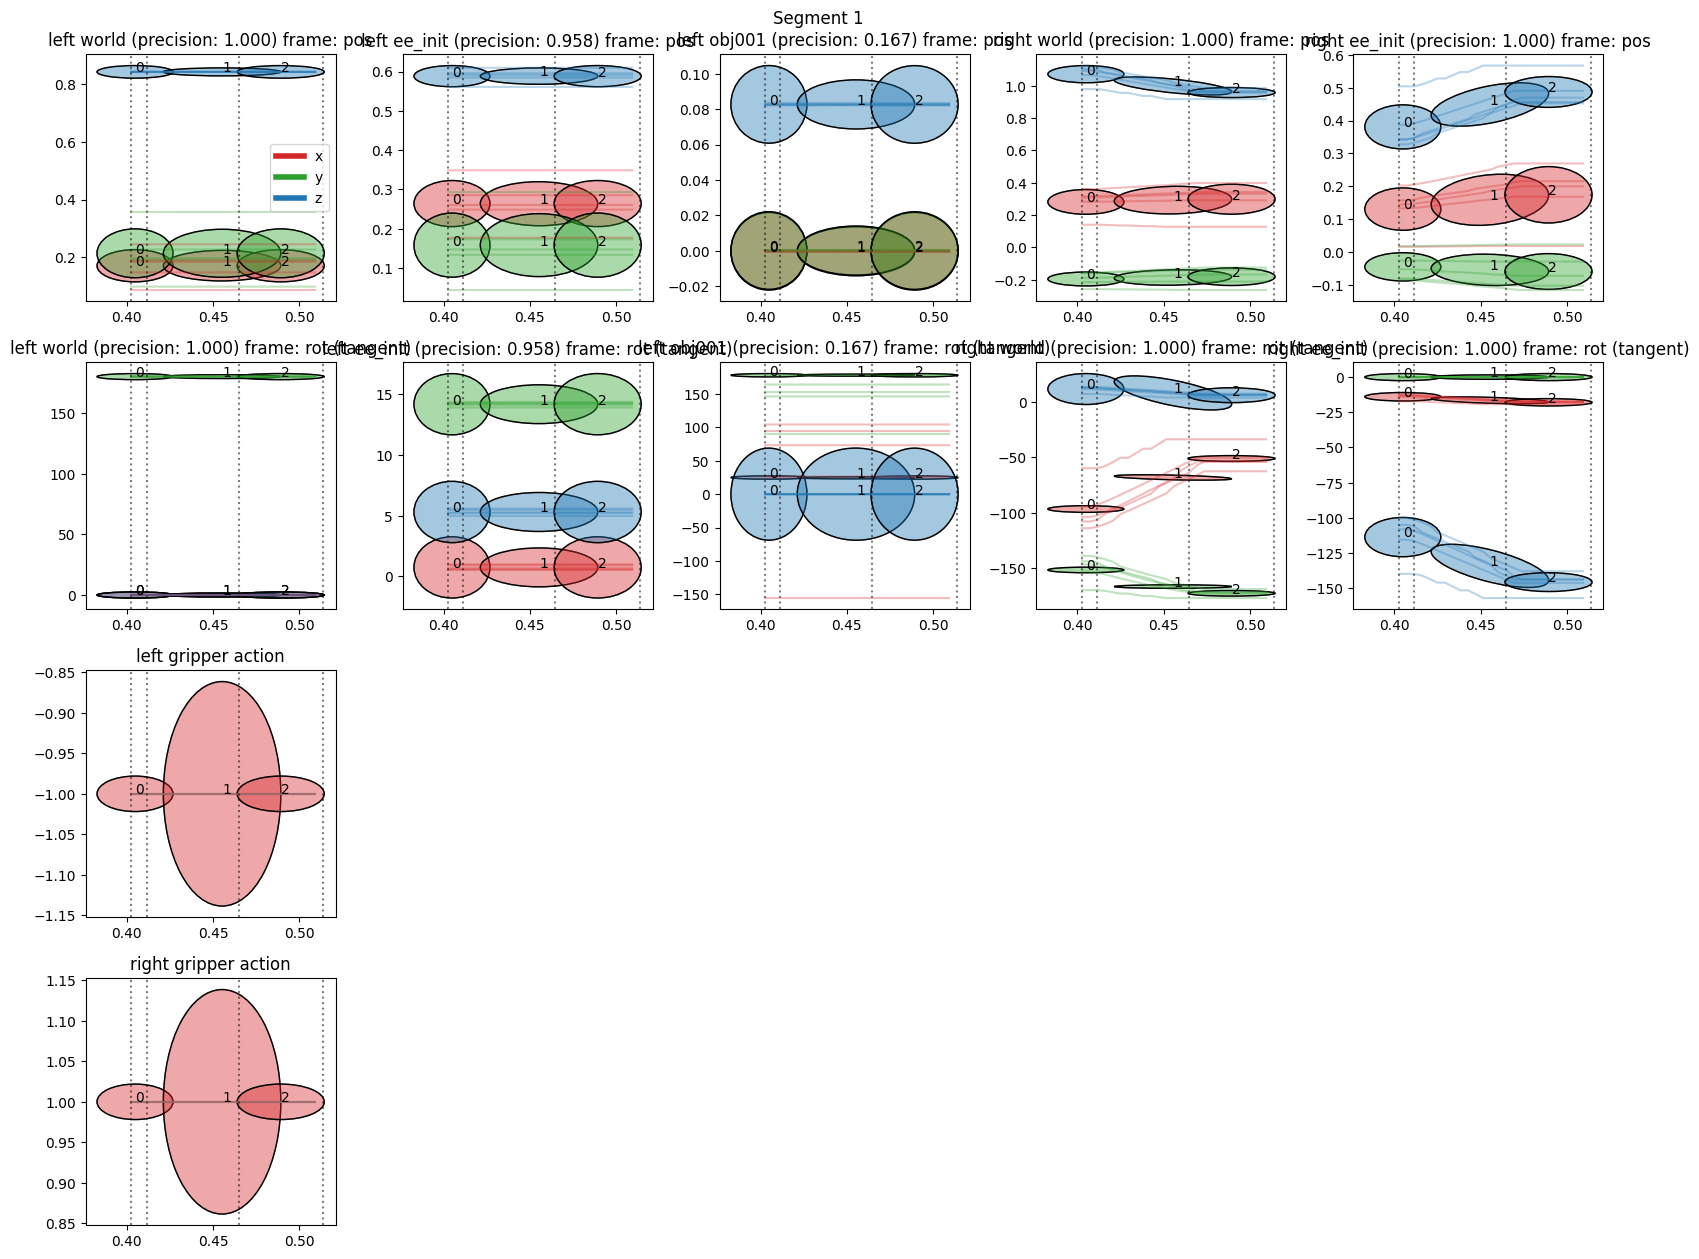

2026-07-27 01:29:10.671 | INFO     |  Did not specify time_based, deciding automatically.


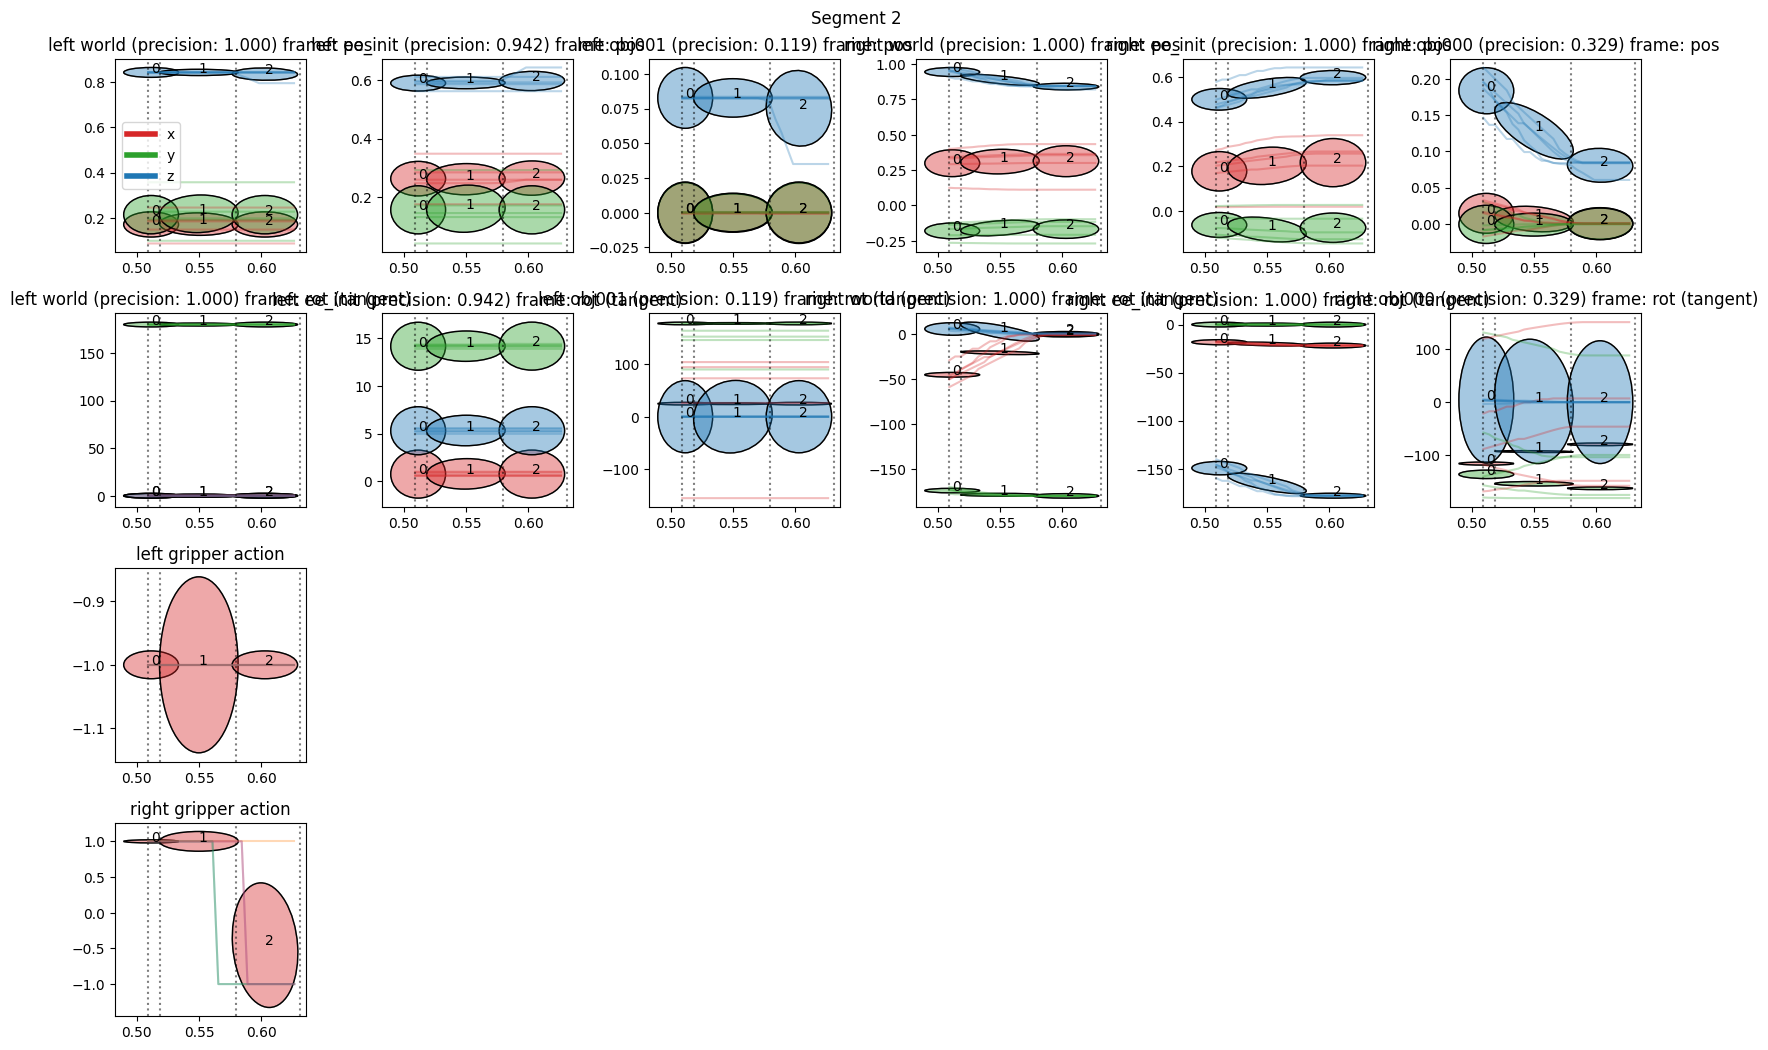

2026-07-27 01:29:14.888 | INFO     |  Did not specify time_based, deciding automatically.


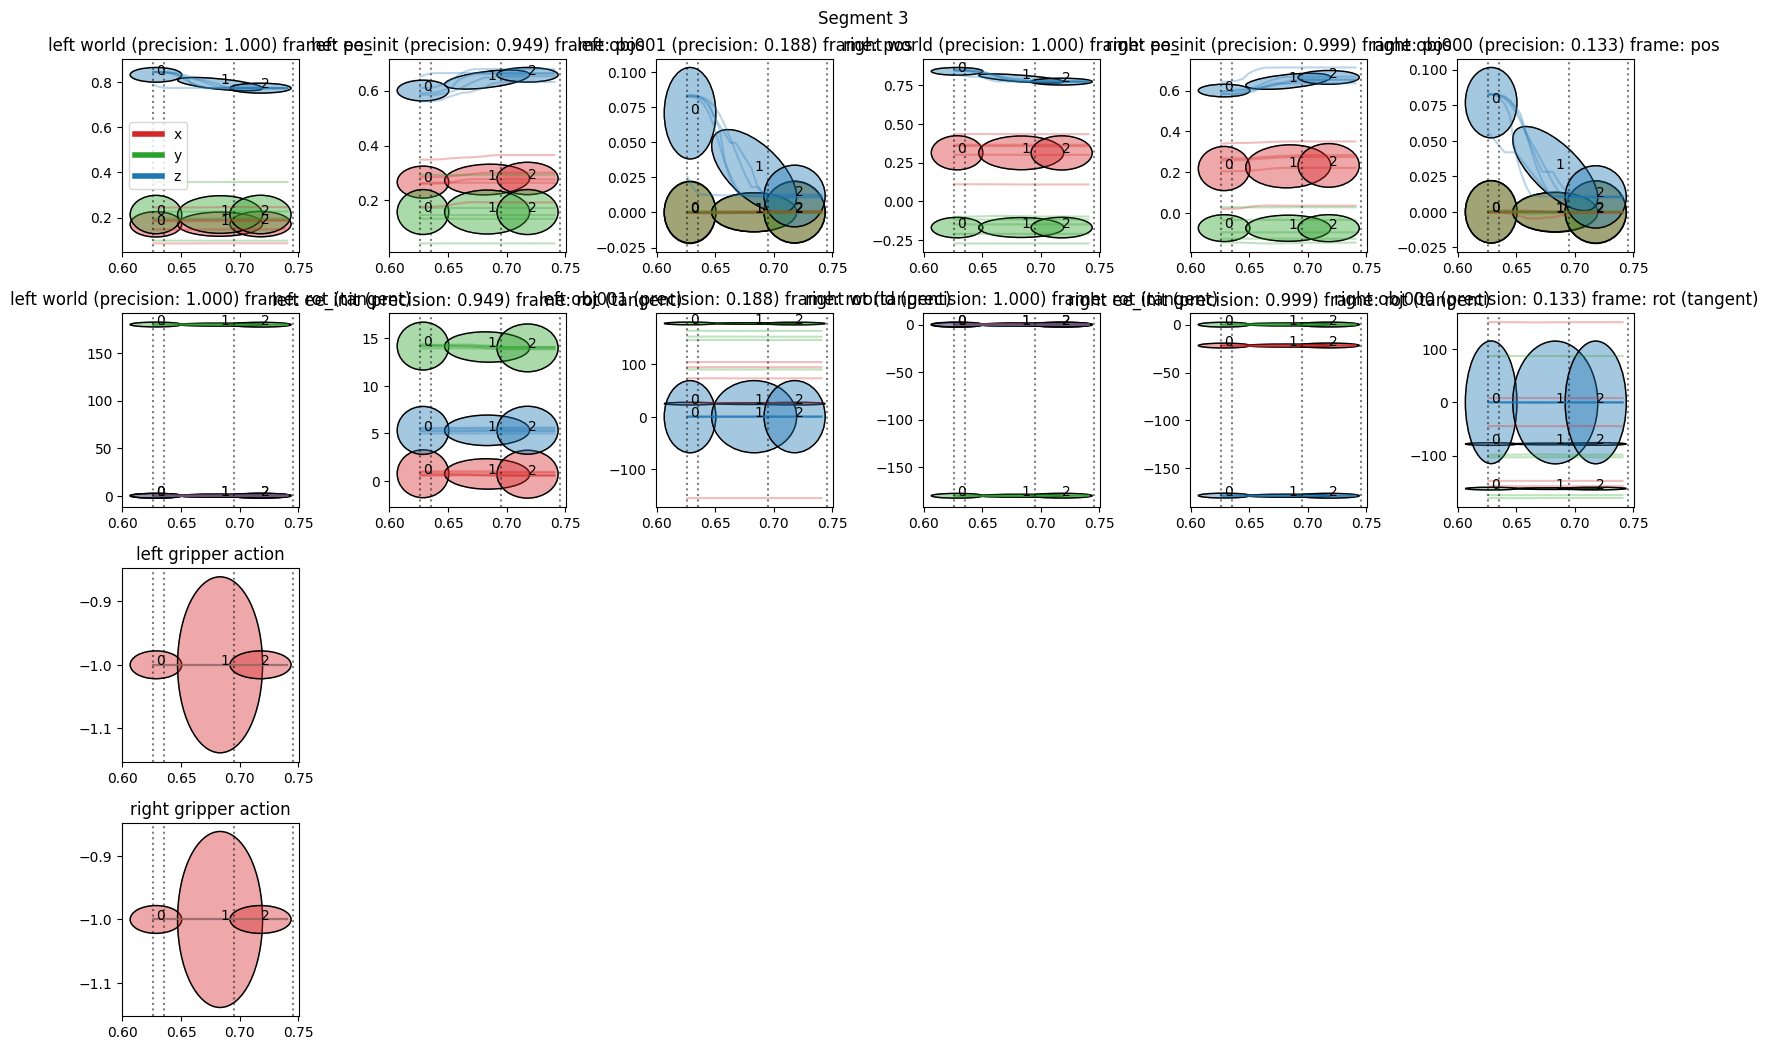

In [4]:
obs = tapas_env.reset()
policy.from_disk(str(model_path))
policy.eval()
policy.reset_episode(tapas_env)

if policy.config.dbg_prediction:
    policy.model.plot_model(
        rotations_raw=False,
        per_segment=True,
        mean_as_base=False,
    )

In [5]:
total_reward = 0
frames = []

for step in range(450):
    action, info = policy.predict(obs)
    obs, reward, done, env_info = tapas_env.step(action)
    frame = obs.cameras["front"].rgb

    if frame.ndim == 4:
        frame = frame[0]

    if frame.shape[0] == 3:
        frame = frame.permute(1, 2, 0)

    frame = (frame * 255).clip(0, 255).byte().cpu().numpy()
    frames.append(frame)
    total_reward += reward

    if obs is None or done or info.get("done", False):
        break

imageio.mimsave(video_dir / "run.mp4", frames, fps=20, format="FFMPEG")

print("steps:", step + 1)
print("total_reward:", total_reward)

tapas_env.close()

2026-07-27 01:29:19.383 | WARNING  |  Implementation lacking modulo rots, enforce z-up/down, etc.


2026-07-27 01:29:19.825 | INFO     |  Action [-7.53711048e-03  2.31272188e-03 -1.09569810e-02 -1.64495832e-02
  7.19686279e-04 -1.33226529e-01  9.90948831e-01  1.00000000e+00
  0.00000000e+00 -8.74919341e-03 -5.69024016e-03 -2.72284158e-02
  8.45784167e-05  1.38371080e-02  3.91682949e-03  9.99896588e-01
  1.00000000e+00  0.00000000e+00]
2026-07-27 01:29:19.837 | INFO     |  Skipping invalid action [-7.53711048e-03  2.31272188e-03 -1.09569810e-02 -1.64495832e-02
  7.19686279e-04 -1.33226529e-01  9.90948831e-01  1.00000000e+00
  0.00000000e+00 -8.74919341e-03 -5.69024016e-03 -2.72284158e-02
  8.45784167e-05  1.38371080e-02  3.91682949e-03  9.99896588e-01
  1.00000000e+00  0.00000000e+00].


2026-07-27 01:29:21.638 | INFO     |  Pos lag: [[-0.00224396  0.00551568 -0.02897926]
 [ 0.00446309  0.00232219 -0.01286275]], quat lag: 0.5385744080408716, pos change [[-2.2777915e-04 -2.0377338e-05  4.4846535e-04]
 [ 2.2523105e-04 -9.2238188e-06  4.1759014e-04]], quat change 0.001953125019402554
2026-07-27 01:29:21.640 | INFO     |  Action [-7.40861311e-03  2.32190277e-03 -1.14229270e-02 -1.63916332e-02
  2.84209357e-04 -1.33232185e-01  9.90949251e-01  1.00000000e+00
  0.00000000e+00 -8.60728321e-03 -5.69067133e-03 -2.77269977e-02
  8.44573372e-05  1.33491150e-02  3.92171958e-03  9.99903202e-01
  1.00000000e+00  0.00000000e+00]
2026-07-27 01:29:21.651 | INFO     |  Skipping invalid action [-7.40861311e-03  2.32190277e-03 -1.14229270e-02 -1.63916332e-02
  2.84209357e-04 -1.33232185e-01  9.90949251e-01  1.00000000e+00
  0.00000000e+00 -8.60728321e-03 -5.69067133e-03 -2.77269977e-02
  8.44573372e-05  1.33491150e-02  3.92171958e-03  9.99903202e-01
  1.00000000e+00  0.00000000e+00].
2026-

/home/nils-schmidt/Dokumente/Study Project/TAPAS/tapas_gmm/utils/geometry_np.py:84: RuntimeWarning: invalid value encountered in arccos
  theta = 2 * np.arccos(2 * np.dot(q, r) ** 2 - 1)


2026-07-27 01:29:22.856 | INFO     |  Pos lag: [[ 3.97407944e-04 -1.17205851e-04  4.68501415e-05]
 [-2.89912175e-04 -4.75155072e-05 -7.75336599e-05]], quat lag: 0.00302572021270737, pos change [[ 0.00315881 -0.00341469  0.01701093]
 [-0.00205226 -0.00154488  0.0111798 ]], quat change 0.0
2026-07-27 01:29:22.858 | INFO     |  Action [ 5.15602246e-03 -5.86993252e-04  1.03170457e-02  1.76710704e-04
 -6.16745378e-04 -3.22741216e-05  9.99999794e-01  1.00000000e+00
  0.00000000e+00  6.76971780e-03  3.79674946e-03  1.57412402e-02
 -2.20906262e-05 -7.96428881e-04  1.70146748e-05  9.99999682e-01
  1.00000000e+00  0.00000000e+00]
2026-07-27 01:29:23.105 | INFO     |  Pos lag: [[ 3.54040194e-04 -1.09936050e-04 -2.06054895e-05]
 [-3.31545399e-04 -5.77825736e-05 -2.44263027e-04]], quat lag: 0.003302689090118745, pos change [[ 0.00324172 -0.00343789  0.01682878]
 [-0.00193629 -0.00153518  0.01145542]], quat change nan
2026-07-27 01:29:23.110 | INFO     |  Action [ 5.15452802e-03 -5.92419008e-04  1.0

...

2026-07-27 01:29:40.218 | INFO     |  Pos lag: [[0.0191624  0.00114563 0.02432189]
 [0.01692969 0.03292151 0.0421767 ]], quat lag: 2.6945569046944904, pos change [[-4.1574240e-05 -2.5661290e-04  3.4213066e-05]
 [ 4.1127205e-05 -7.3879957e-05 -4.7385693e-05]], quat change 0.002392079862581466
2026-07-27 01:29:40.220 | INFO     |  Action [-1.97013320e-02  5.50679374e-03  5.22863724e-02  8.48614339e-02
  5.62617167e-01 -2.55792506e-01 -7.81556559e-01  0.00000000e+00
  0.00000000e+00  1.01293936e-02 -6.26556687e-03  2.86195762e-02
  1.61431730e-02  2.70218964e-02  2.20299794e-04  9.99504460e-01
  0.00000000e+00  0.00000000e+00]
2026-07-27 01:29:40.368 | INFO     |  Pos lag: [[0.01910121 0.00161783 0.02438413]
 [0.01692209 0.03285952 0.0421601 ]], quat lag: 2.6936364753936175, pos change [[ 6.1869621e-05 -4.6922266e-04 -4.4882298e-05]
 [ 1.5407801e-05  5.6549907e-05  5.3465366e-05]], quat change 0.0030881618542035155
2026-07-27 01:29:40.369 | INFO     |  Action [-1.96139052e-02  5.46074059e

2026-07-27 01:29:40.505 | INFO     |  Pos lag: [[0.01913333 0.00166606 0.02436086]
 [0.01695408 0.03288727 0.04218992]], quat lag: 2.694281805602282, pos change [[-3.1650066e-05 -4.5180321e-05  4.0531158e-05]
 [-2.4199486e-05 -3.3184886e-05  7.0333481e-06]], quat change 0.0013810679388648144
2026-07-27 01:29:40.507 | INFO     |  Action [-1.96369705e-02  5.49016298e-03  5.23093439e-02  8.44660178e-02
  5.62468337e-01 -2.56119368e-01 -7.81599469e-01  0.00000000e+00
  0.00000000e+00  9.90181715e-03 -6.74041174e-03  2.86304366e-02
  1.63847471e-02  2.71632304e-02  4.40307814e-04  9.99496626e-01
  0.00000000e+00  0.00000000e+00]
2026-07-27 01:29:40.688 | INFO     |  Pos lag: [[0.01915266 0.00175112 0.02436251]
 [0.01700879 0.03290241 0.04219834]], quat lag: 2.6945427277318923, pos change [[-1.8864870e-05 -8.2015991e-05  1.5616417e-05]
 [-4.6908855e-05 -2.0578504e-05  2.8431416e-05]], quat change 0.0013810679388648144
2026-07-27 01:29:40.690 | INFO     |  Action [-1.96353771e-02  5.49114739e

2026-07-27 01:29:40.839 | INFO     |  Pos lag: [[0.01913301 0.00174458 0.0243917 ]
 [0.01708873 0.03296191 0.04211932]], quat lag: 2.6928001842480866, pos change [[ 2.0116568e-05  9.5814466e-06 -1.1920929e-05]
 [-7.2151423e-05 -6.4939260e-05  1.1587143e-04]], quat change 0.001953125019402554
2026-07-27 01:29:40.841 | INFO     |  Action [-1.96003653e-02  5.31304442e-03  5.23751872e-02  8.44469194e-02
  5.62443678e-01 -2.55473863e-01 -7.81830501e-01  0.00000000e+00
  0.00000000e+00  9.88062706e-03 -6.80474507e-03  2.86532748e-02
  1.63519281e-02  2.74296261e-02  6.21051141e-04  9.99489792e-01
  0.00000000e+00  0.00000000e+00]
2026-07-27 01:29:41.001 | INFO     |  Pos lag: [[0.01917213 0.00178284 0.02439728]
 [0.01693255 0.03289664 0.0424319 ]], quat lag: 2.694291542855426, pos change [[-3.8653612e-05 -3.5211444e-05  1.1682510e-05]
 [ 1.6397238e-04  5.9828162e-05 -2.7573109e-04]], quat change 0.0013810679388648144
2026-07-27 01:29:41.002 | INFO     |  Action [-1.96823032e-02  5.66430473e-

2026-07-27 01:29:41.346 | INFO     |  Pos lag: [[-0.01300769  0.01254001  0.15158949]
 [ 0.017036    0.0328603   0.04235848]], quat lag: 2.69487155436176, pos change [[-1.0806143e-02  3.9459914e-03 -4.3697357e-03]
 [-9.5665455e-05  3.0905008e-05  1.1026859e-04]], quat change 0.5639392678369933
2026-07-27 01:29:41.347 | INFO     |  Action [-0.04816109  0.12766478  0.14414929  0.0934058   0.55932661 -0.26237182
 -0.78076253  0.          0.         -0.09979152  0.02241781  0.13761681
 -0.03739887 -0.09977435  0.00814174  0.99427366  0.          0.        ]


2026-07-27 01:29:41.571 | INFO     |  Pos lag: [[-0.01314379  0.01264203  0.17107674]
 [-0.01249883  0.03609765  0.19480595]], quat lag: 2.6996882021578816, pos change [[ 5.4076314e-04 -3.5554171e-05 -5.4365396e-04]
 [-2.5799870e-04 -1.3363361e-04 -2.2292137e-05]], quat change 0.0760226303393602
2026-07-27 01:29:41.572 | INFO     |  Action [-0.04822032  0.12729178  0.1444999   0.09267373  0.55934396 -0.26261463
 -0.78075571  0.          0.         -0.10557555  0.02360321  0.13377788
 -0.04136728 -0.11823107  0.00837513  0.99208872  0.          0.        ]
steps: 66
total_reward: 0.0
[CoppeliaSim:loadinfo]   done.


In [6]:
tapas_env.close()